<h10>
This module is Zepto's analyst-to-data-scientist workflow in one pass: profile a dataset, handle its imperfections defensibly, tell a clear visual story about it, and then build and rigorously evaluate a full predictive-modeling pipeline on top of the same data. Load the classic Titanic dataset once, through Seaborn's built-in loader: sns.load_dataset('titanic').
</h10> <br>
<h12>
<br>
Tasks <br>
Part A — Profiling, cleaning, and the data story
</h12> <br>
Task-1: <br>
Load the dataset and profile it: print df.info(), df.describe(), and df.shape. 
Compute and report the percentage of missing values in every column that has any. 
Immediately after loading, save the loaded DataFrame as a committed offline fallback <br>
 — df.to_csv("titanic.csv", index=False). <br>
 This is the one and only load of the raw dataset: <br>
 — including the modeling pipeline — works from this same DataFrame or its saved CSV.

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler

df_titanic = sns.load_dataset('titanic')

# No.of rows and columns in the dataset
df_titanic.shape

# Display the summary of the dataset
df_titanic.info()

# Display the statistical summary of the dataset
df_titanic.describe()

# Columns in the dataset
df_titanic.columns

# To check missing values in the dataset
missing_values = df_titanic.isnull().sum()

missing_values_percentage = (missing_values / len(df_titanic)) * 100

print("Percentage of missing values in each column:")
print(missing_values_percentage)

# Save the loaded DataFrame as a committed offline fallback
#df_titanic.to_csv("titanic.csv", index=False)////

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB
Percentage of missing values in each column:
survived        0.000000
pclass          0.000000

In [ ]:
#--------------------------------------------------------------------------------------------------
# Task-2:
# Apply missing-value handling per column, following this threshold rule (under 5% missing → 
# Handling missing values based on the threshold rule:
# under 5% missing → drop those rows; 5%–30% missing → impute) — and for any column whose 
# missing rate is so high that imputation would be unreliable, explicitly decide to either drop 
# the column or encode "missing" as its own category, and justify that decision in writing. 
# State the exact percentage you measured for each affected column before choosing its strategy.
# 1. Drop rows with missing values in 'embarked' column (0.22% missing)
#---------------------------------------------------------------------------------------------------
# Dropping columnL 'embarked' - as it doesn't have any feature importance
df_titanic = df_titanic.dropna(subset=['embarked'])

# Drop rows with missing values in 'embark_town' column (0.22% missing)
#df_titanic = df_titanic.dropna(subset=['embark_town'])

# 2. Impute missing values in 'age' column (19.87% missing) with the median age
df_titanic['age'] = df_titanic['age'].fillna(df_titanic['age'].mean()) #, inplace=True)
df_titanic.head(50)

# The deck column contains approximately 77.22% missing values. Since the proportion of missing values 
# is very high, imputing the column may introduce bias and reduce its reliability. Therefore, the column 
# is dropped from the dataset.
df_titanic.dropna(subset=['deck'])

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
10,1,3,female,4.0,1,1,16.7000,S,Third,child,False,G,Southampton,yes,False
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,1,1,female,47.0,1,1,52.5542,S,First,woman,False,D,Southampton,yes,False
872,0,1,male,33.0,0,0,5.0000,S,First,man,True,B,Southampton,no,True
879,1,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,yes,False
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True


Outlier counts:
{'fare': 114, 'age': 65}


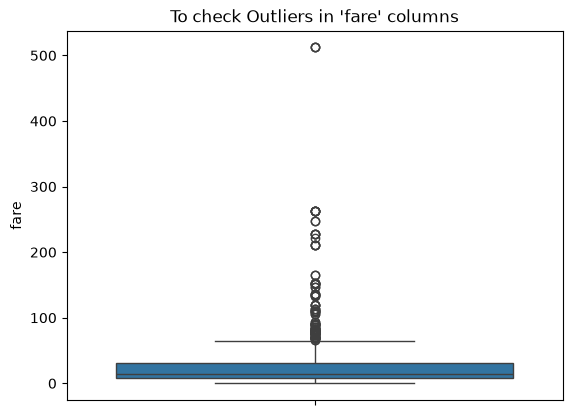

In [69]:
'''
Task.3: 
Univariate analysis: plot a histogram and a box plot for both age and fare. Using the IQR rule (outliers are points outside 
[Q1 - 1.5*IQR, Q3 + 1.5*IQR]), report how many outliers each column has. Compute mean, median, and mode for fare, and state in 
writing whether its distribution is right-skewed, left-skewed, or symmetric, referencing the mean/median/mode ordering.
'''
#fig = plt.subplots(1, 2, figsize=14, vert=True)

# Boxplot on fare
sns.boxplot(df_titanic['fare'])
plt.title("To check Outliers in 'fare' columns")

# Numeric columns
# numeric_cols = df_titanic.select_dtypes(include='number').columns

# fetching Numeric columns - 'fare' and 'age'
numeric_cols = df_titanic[['fare', 'age']]

# Count outliers using IQR rule
outlier_counts = {}

for col in numeric_cols:
    Q1 = df_titanic[col].quantile(0.25)
    Q3 = df_titanic[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_titanic[(df_titanic[col] < lower_bound) | (df_titanic[col] > upper_bound)]
    outlier_counts[col] = len(outliers)

print("Outlier counts:")
print(outlier_counts)

In [70]:
#Checking 'fare' columns values are left skewed or right skewed
fare_mean = df_titanic['fare'].mean()
fare_median = df_titanic['fare'].median()
fare_mode = df_titanic['fare'].mode()[0]

print(f"\nfare_mean: {fare_mean:,.4f} \nfare_median: {fare_median} \nfare_mode: {fare_mode}\n")
if (fare_mean > fare_median >  fare_mode):
    print("Fare column data distribution is right skewed")
elif (fare_mean < fare_median <  fare_mode):
    print("Fare column data distribution is left skewed")
else:
    print("Fare column data distribution is symmetric")


fare_mean: 32.0967 
fare_median: 14.4542 
fare_mode: 8.05

Fare column data distribution is right skewed


In [71]:
# Checking 'fare' columns values 

There are outliers in 'age' column as well


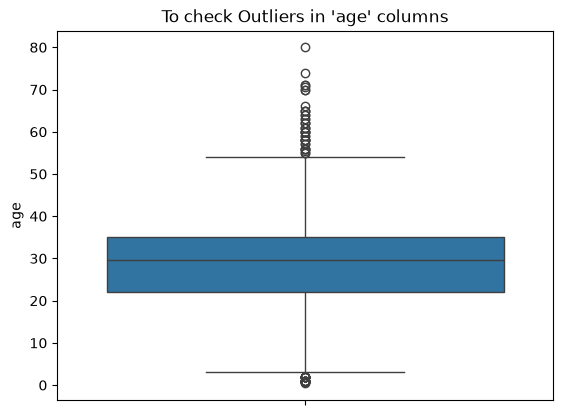

In [72]:
# Boxplot on Column: 'Age'
sns.boxplot(df_titanic['age'])
plt.title("To check Outliers in 'age' columns")
print("There are outliers in 'age' column as well")

Text(0.5, 1.0, "Histogram plot - to represent 'fare' increase")

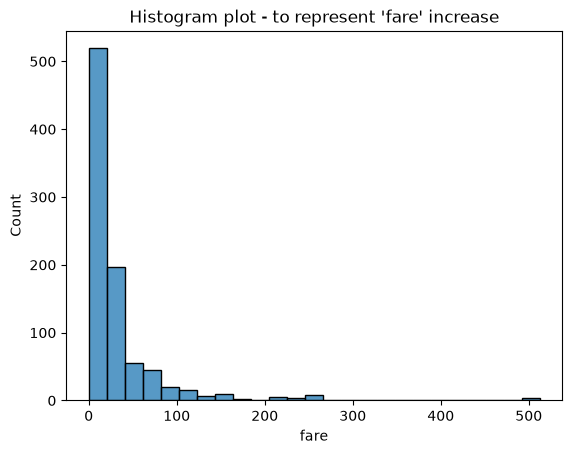

In [73]:
# Hostogram on Fare Column
sns.histplot(df_titanic['fare'], bins=25)
plt.title("Histogram plot - to represent 'fare' increase")

<Axes: title={'center': 'Histogram Plot - to represent no.of passengers boarded (both male/female and senior citizen)'}, xlabel='age', ylabel='Count'>

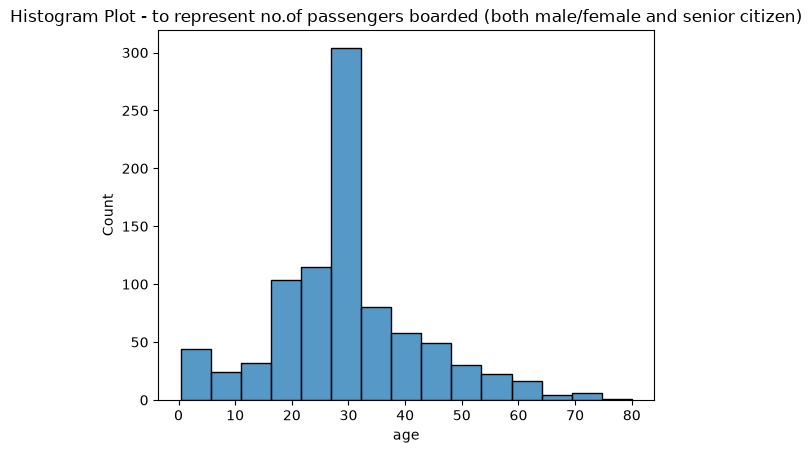

In [74]:
# Hostogram on Age Column
plt.title("Histogram Plot - to represent no.of passengers boarded (both male/female and senior citizen)")
sns.histplot(df_titanic['age'], bins=15)

In [75]:
'''
Task.4: 
Bivariate analysis: using boolean masking (with &/| combinations), compute and report survival rate 
broken down by (a) sex, (b) pclass, and (c) sex and pclass together. Then compute a correlation matrix 
restricted to exactly these six columns: survived, pclass, age, sibsp, parch, and fare — the dataset's 
numeric columns, including survived (0/1-valued) as the natural numeric target. Exclude the boolean-typed 
columns adult_male and alone from the correlation matrix: they are derived/redundant flags (directly computable 
from sex/age and from sibsp+parch respectively), not independent measured features. Render the resulting 6×6 matrix 
as a heatmap using sns.heatmap, with a short written interpretation of the two strongest correlations you observe — 
defined precisely as the two feature pairs with the largest absolute off-diagonal correlation coefficients (rank all 
off-diagonal pairs by abs(correlation) and take the top two).
'''
# --------------------------------------------------
# Subtask-1 Survival rate by Sex
# --------------------------------------------------
male_mask = df_titanic['sex'] == 'male'
female_mask = df_titanic['sex'] == 'female'

male_survival_rate = df_titanic.loc[male_mask, 'survived'].mean()
female_survival_rate = df_titanic.loc[female_mask, 'survived'].mean()

print("Survival Rate by Sex:")
print(f"Male:   {male_survival_rate:.2%}")
print(f"Female: {female_survival_rate:.2%}")

# --------------------------------------------------
# Subtask-2 Survival rate by Pclass
# --------------------------------------------------

print("Survival Rate by Pclass:")
for pclass in sorted(df_titanic['pclass'].dropna().unique()):
    mask = df_titanic['pclass'] == pclass
    survival_rate = df_titanic.loc[mask, 'survived'].mean()

    print(f"Pclass {pclass}: {survival_rate:.2%}")

# --------------------------------------------------
# Subtask-3 Survival rate by Sex AND Pclass
# --------------------------------------------------

print("\nSurvival Rate by Sex and Pclass:")

for sex in ['male', 'female']:
    for pclass in sorted(df_titanic['pclass'].dropna().unique()):

        mask = (
            (df_titanic['sex'] == sex) &
            (df_titanic['pclass'] == pclass)
        )

        survival_rate = df_titanic.loc[mask, 'survived'].mean()

        print(
            f"{sex.capitalize()}, Pclass {pclass}: "
            f"{survival_rate:.2%}"
        )

#-------------------------------------------------------------------------------------------------
# Subtask-4 compute a correlation matrix restricted to exactly these six columns: survived, pclass, 
# age, sibsp, parch, and fare — the dataset's numeric columns, including survived (0/1-valued) as 
# the natural numeric target. Exclude the boolean-typed columns adult_male and alone from the 
# correlation matrix
#----------------------------------------------------------------------------------------------------
corr_cols = [
    'survived',
    'pclass',
    'age',
    'sibsp',
    'parch',
    'fare'
]

corr_matrix = df_titanic[corr_cols].corr() # automatically excludes: adult_male alone

print("\nCorrelation Matrix:")
print(corr_matrix.round(3))



Survival Rate by Sex:
Male:   18.89%
Female: 74.04%
Survival Rate by Pclass:
Pclass 1: 62.62%
Pclass 2: 47.28%
Pclass 3: 24.24%

Survival Rate by Sex and Pclass:
Male, Pclass 1: 36.89%
Male, Pclass 2: 15.74%
Male, Pclass 3: 13.54%
Female, Pclass 1: 96.74%
Female, Pclass 2: 92.11%
Female, Pclass 3: 50.00%

Correlation Matrix:
          survived  pclass    age  sibsp  parch   fare
survived     1.000  -0.336 -0.075 -0.034  0.083  0.255
pclass      -0.336   1.000 -0.328  0.082  0.017 -0.548
age         -0.075  -0.328  1.000 -0.232 -0.178  0.089
sibsp       -0.034   0.082 -0.232  1.000  0.415  0.161
parch        0.083   0.017 -0.178  0.415  1.000  0.218
fare         0.255  -0.548  0.089  0.161  0.218  1.000


In [76]:
#-----------------------------------------------------------------------------------------------------
# Subtask-5 Render the resulting 6×6 matrix as a heatmap using sns.heatmap, with a short written 
# interpretation of the two strongest correlations you observe — defined precisely as the two feature 
# pairs with the largest absolute off-diagonal correlation coefficients (rank all off-diagonal pairs by 
# abs(correlation) and take the top two).
#-------------------------------------------------------------------------------------------------------
# To find two strongest correlations in correlation matrix
upper = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

correlation_pairs = (
    upper.stack()
    .reset_index()
)

correlation_pairs.columns = [
    'Feature 1',
    'Feature 2',
    'Correlation'
]

correlation_pairs['Abs_Correlation'] = (
    correlation_pairs['Correlation'].abs()
)

top_two = correlation_pairs.sort_values(
    'Abs_Correlation',
    ascending=False
).head(2)

print("\nTwo Strongest Correlations:")
print(top_two[['Feature 1', 'Feature 2', 'Correlation']])


Two Strongest Correlations:
   Feature 1 Feature 2  Correlation
11    pclass      fare    -0.548193
22     sibsp     parch     0.414542


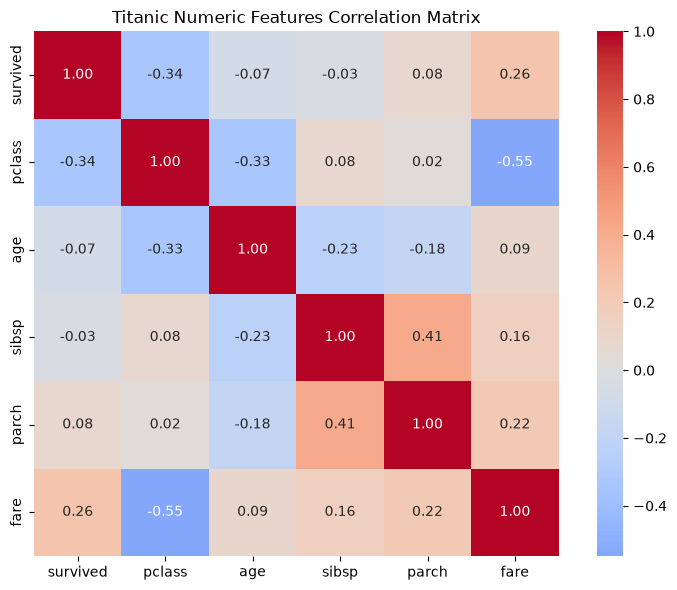

In [77]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Titanic Numeric Features Correlation Matrix")
plt.tight_layout()
plt.show()

(0.0, 1.0)

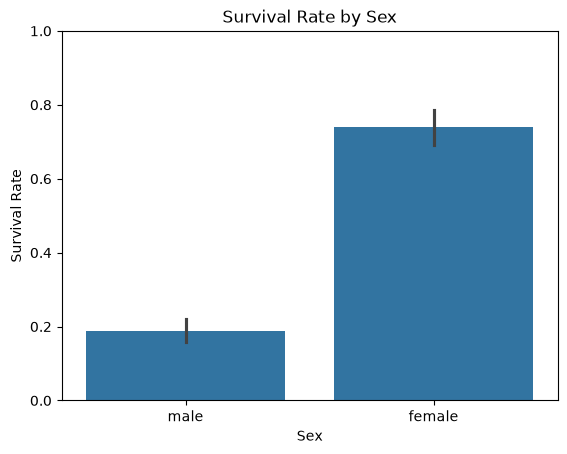

In [78]:
''' 
Task-5: 
Multivariate "data story": produce at least 4 distinct charts (any combination of bar/box/scatter
/heatmap/pair-plot) that together build a coherent argument about who was more likely to survive and why. 
Each chart must be accompanied by a 2-4 sentence written interpretation in your README/notebook — a chart 
with no interpretation does not count.
'''
# Bar plot - on 'class' and 'pclass' columns - to compare categorical with numeric data
sns.barplot(df_titanic, x='sex', y='survived')
plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")
plt.ylim(0,1)

#df_titanic.info()

(0.0, 1.0)

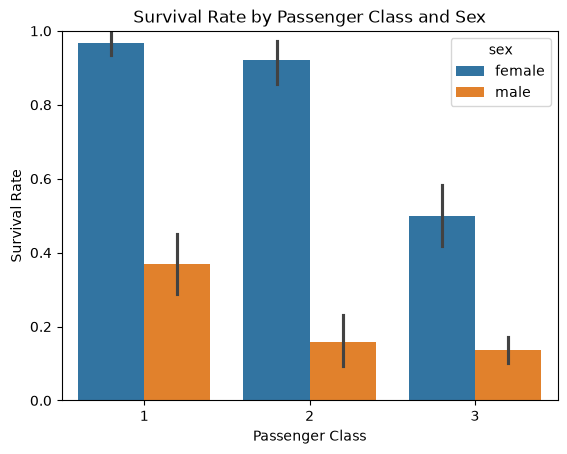

In [79]:
# Bar plot - on 'class' Vs 'survived'
sns.barplot(df_titanic, x='pclass', y='survived', hue='sex')
plt.title("Survival Rate by Passenger Class and Sex")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)


<Figure size 1000x800 with 0 Axes>

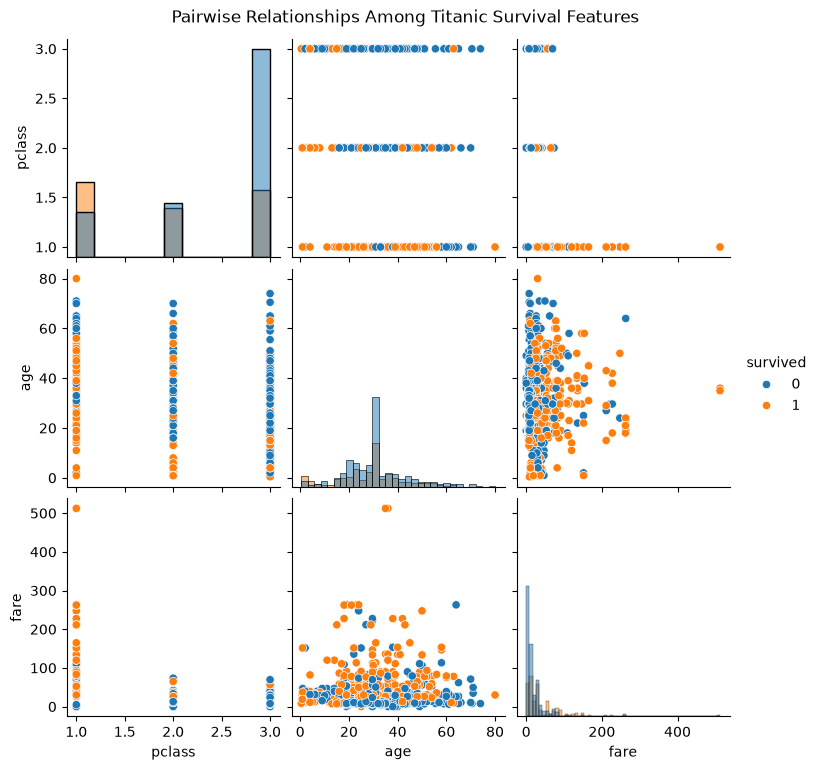

In [80]:
# Pair plot - on 'pclass', 'sibsp', 'parch' columns
plt.figure(figsize=(10,8))
sns.pairplot(df_titanic[['survived', 'pclass', 'age', 'fare']], hue='survived', diag_kind='hist')

plt.suptitle(
    "Pairwise Relationships Among Titanic Survival Features",
    y=1.02
)

plt.show()

Text(0, 0.5, 'Age')

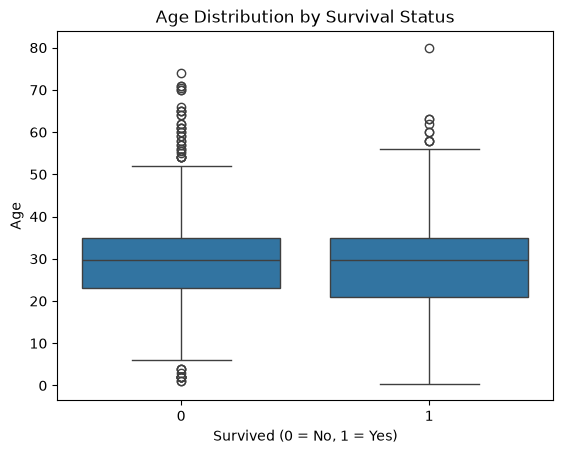

In [81]:
# Age distribution by survival status
sns.boxplot(df_titanic, y='age', x='survived')

plt.title("Age Distribution by Survival Status")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age")

In [ ]:
'''
Task-6
As an exploratory check (not yet the modeling pipeline's own preprocessing — that is handled separately 
in Task 8 below), standardize age and fare using the z-score formula z = (x − mean) / std on the full cleaned 
DataFrame (you may use StandardScaler or compute it manually). Show a before/after comparison (e.g., a printed 
summary of means/stds, or overlaid distribution plots) confirming the transformed columns have (approximately) 
mean 0 and standard deviation 1. This is purely an EDA-stage         
# *sanity check:* It does not feed into the modeling pipeline, which performs its own train-only scaling.
'''
# Checking null values count in both age and fare
df_titanic[['age', 'fare']].isnull().sum()

# Before scaling (using z-score)
print("Before scaling (using z-score)")
print(df_titanic[['age', 'fare']].agg(['mean', 'std']).round(4))

scaler = StandardScaler()

df_titanic[['age_z', 'fare_z']] = scaler.fit_transform(
    df_titanic[['age', 'fare']]
)

# After Scaling
print("\nAFTER STANDARDIZATION")
print(df_titanic[['age_z', 'fare_z']].agg(['mean', 'std']).round(4))


Before scaling (using z-score)
          age     fare
mean  29.6421  32.0967
std   12.9683  49.6975

AFTER STANDARDIZATION
       age_z  fare_z
mean -0.0000  0.0000
std   1.0006  1.0006


In [83]:
# Saving cleaned dataset to 'titanic.csv' file
df_titanic.to_csv('titanic.csv')